In [59]:
import pandas as pd
import numpy as np

# House Building Starts

## UK
Source: Indicators of House Building: https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/ukhousebuildingpermanentdwellingsstartedandcompleted

Table: 1b, 1c, 1d

Region: GB

Key Column: Started - Private Enterprises

In [60]:
with pd.ExcelFile("../data/raw/starts/indicatorsofukhousebuilding.xlsx") as xls:
    eng = pd.read_excel(xls, sheet_name='1b', skiprows=5, index_col=1)
    wal = pd.read_excel(xls, sheet_name='1c', skiprows=5, index_col=1)
    sco = pd.read_excel(xls, sheet_name='1d', skiprows=5, index_col=1)

df_list = [eng, wal, sco]

for df in df_list:
    df.drop("Revised", axis=1, inplace=True)

# Cropping out wales dates
wal = wal.iloc[15:]

df_combined = pd.concat({
    'England' : eng['Started - Private Enterprise'],
    'Wales' : wal['Started - Private Enterprise'],
    'Scotland' : sco['Started - Private Enterprise']}, axis=1)

# Applies the numeric conversion for Wales strings
df_combined = df_combined.apply(pd.to_numeric, errors='coerce')

df_combined['SUM'] = df_combined.sum(axis=1)

# Mapping quarters
quarter_map = {
    "Jan - Mar": "Q1",
    "Apr - Jun": "Q2",
    "Jul - Sep": "Q3",
    "Oct - Dec": "Q4"
}

# Clean up index
idx_str = df_combined.index.astype(str).str.strip()

# Extract the month range text and the 4-digit year
months = idx_str.str.extract(r'(Jan - Mar|Apr - Jun|Jul - Sep|Oct - Dec)')[0]
years = idx_str.str.extract(r'(\d{4})')[0]

# Translate the months into Q1, Q2, etc.
quarters = months.map(quarter_map)

# Glue into strings
quarter_strings = years + quarters

# Convert to Period objects
df_combined.index = pd.PeriodIndex(quarter_strings, freq='Q')

# Naming index
df_combined.index.name = 'Date'

# Adding MEEN data
meen_sums = [
    28800, 41600, 41400, 37400,
    37200, 46500, 42800, 28100,
    26200, 38100, 39100, 31400
]

# Generate quarter indices
meen_quarters = pd.period_range(start='1975Q1', periods=len(meen_sums), freq='Q')

# Creating new df with jut sum col
df_meen = pd.DataFrame({'SUM': meen_sums}, index=meen_quarters)
df_meen.index.name = 'Date'

# Concat with combined
df_combined = pd.concat([df_meen, df_combined], axis=0)
# Saving to csv
df_combined.to_csv('../data/python_master/starts/UK_starts_series.csv', index=True)

# England
We scale the rows from 1975Q1 - 1977Q4 by 0.825 then just use the England series

In [61]:
df_eng = pd.read_csv('../data/python_master/starts/UK_starts_series.csv', index_col=0, usecols=[0,1,2])

# Scaling by 0.846
df_eng.loc[:'1977Q4', 'SUM'] = df_eng.loc[:'1977Q4', 'SUM'] * 0.846

# Filling in values from SUM
df_eng.loc[:'1977Q4', 'England'] = df_eng.loc[:'1977Q4', 'SUM']

# Keeping Columns we need
df_eng = df_eng["England"]

df_eng.to_csv('../data/python_master/starts/ENG_starts_series.csv', index=True)

# Nominal House Prices
# UK
Source: UK House Price Index: data downloads March 2026 (Average Price) - extract UK data
https://www.gov.uk/government/statistical-data-sets/uk-house-price-index-data-downloads-march-2026

In [62]:
df = pd.read_csv('../data/raw/nominal_house_price/Average-prices-2026-03.csv', index_col=0, parse_dates=[0])

df.drop(columns=['Area_Code', 'Monthly_Change', 'Annual_Change', 'Average_Price_SA'], inplace=True)

In [63]:
# Filtering to UK
df_uk = df[df['Region_Name'] == 'United Kingdom']

# Filtering date from Jan 1975
df_uk = df_uk.loc['1975-01-01':]

# Taking sums of months for quarters
df_uk = df_uk.resample('QE').mean(numeric_only=True)

# Adding Region Name back
df_uk['Region_Name'] = 'United Kingdom'

# Move to front
df_uk = df_uk[['Region_Name'] + [col for col in df_uk.columns if col != 'Region_Name']]

# Keeping only columns we need
df_uk = df_uk["Average_Price"]

# Converting to periods
df_uk.index = df_uk.index.to_period('Q')

df_uk.to_csv("../data/python_master/house_price/UK_house_price.csv")

# England
Same exact method but filter for England

In [64]:
# Filtering to UK
df_eng = df[df['Region_Name'] == 'England']

# Filtering date from Jan 1975
df_eng = df_eng.loc['1975-01-01':]

# Taking sums of months for quarters
df_eng = df_eng.resample('QE').mean(numeric_only=True)

# Adding Region Name back
df_eng['Region_Name'] = 'England'

# Move to front
df_eng = df_eng[['Region_Name'] + [col for col in df_eng.columns if col != 'Region_Name']]

# Converting to periods
df_eng.index = df_eng.index.to_period('Q')

# Keeping only columns we need
df_eng = df_eng["Average_Price"]

df_eng.to_csv("../data/python_master/house_price/ENG_house_price.csv")

In [65]:
df_eng

Date
1975Q1      8264.000000
1975Q2      8501.000000
1975Q3      8702.000000
1975Q4      8812.000000
1976Q1      8958.000000
              ...      
2025Q1    288935.333333
2025Q2    284692.666667
2025Q3    292045.000000
2025Q4    292265.666667
2026Q1    290280.333333
Freq: Q-DEC, Name: Average_Price, Length: 205, dtype: float64

# Construction Costs
## Both UK and England
SPLICE

1st Series:
BIS quarterly construction price and cost indices: July to September 2014 - Output price indices July to September 2014

https://www.gov.uk/government/statistics/bis-quarterly-construction-price-and-cost-indices-july-to-september-2014

Table 1 Tab

Key Variable: Private Housing


2nd Series:
ONS Construction output price indices

https://www.ons.gov.uk/businessindustryandtrade/constructionindustry/datasets/interimconstructionoutputpriceindices

New work tab

Key Variable: Housing (public and private)  index 2015=100


## IMPORTANT: Rebasing of second series is necessary

In [66]:
bis = pd.read_excel('../data/raw/construction_cost/14-p157e-output-price-indices-2014Q2_rev1.xls',
                    sheet_name='Table 1',
                    skiprows=148,
                    usecols=[1,2,5],)

# Cropping comments
bis = bis.iloc[:-6]

bis.columns = ['Year', 'Quarter', 'Output Price']

# Forward fill missing years
bis['Year'] = bis['Year'].ffill()

bis.index = pd.PeriodIndex([f"{y}Q{q}" for y, q in zip(bis['Year'], bis['Quarter'].astype(str).str.replace('Q', ''))], freq='Q')

bis = bis.drop(columns=['Year', 'Quarter'])

# Setting last known 2014 value as anchor for ONS splice
anchor = bis['Output Price'].iloc[-1]

In [67]:
ons = pd.read_excel('../data/raw/construction_cost/bulletindataset9.xlsx',
                    sheet_name='New work',
                    skiprows=4,
                    usecols=[0,1],)

# Extract the Year and Month into separate working columns
# If the row contains a 4-digit number (like 2014), extract it as the year
ons['Year'] = ons['Time period'].str.extract(r'(\d{4})')
ons['Month'] = ons['Time period'].str.replace(r'\d{4}\s*', '', regex=True)

# 2. Forward-fill the Year column down the empty rows
ons['Year'] = ons['Year'].ffill()

# 3. Combine Year and Month into a standard string format (e.g., "2014 Jan")
ons['Date_String'] = ons['Year'] + ' ' + ons['Month']

# 4. Convert that string into a true pandas Datetime index
ons.index = pd.to_datetime(ons['Date_String'], format='%Y %b')

# 5. Clean up the DataFrame by dropping the temporary columns
ons = ons.drop(columns=['Time period', 'Year', 'Month', 'Date_String'])

ons.columns =['Output_Index']
# Calculating rolling average
ons['3_Month_Rolling_Avg'] = ons['Output_Index'].rolling(window=3).mean()

# Picking every 3rd value for quarterly values
ons_quart = ons['3_Month_Rolling_Avg'].iloc[2::3]

# Dropping first 2014 Q1 value as we have BIS
ons_quart = ons_quart.iloc[1:]

# Applying rebasing (* [anchor / 100])
ons_quart = ons_quart * (anchor / 100)

# Convert to quarters
ons_quart.index = pd.PeriodIndex(ons_quart.index, freq='Q')

In [68]:
# Concatenating series
lrcc = pd.concat([bis['Output Price'], ons_quart])

# Saving series
lrcc.to_csv("../data/python_master/construction/UK_cc.csv")

# Transactions

Region: England & Wales (NO UK)

1st Source: Geoffrey Meen HARCODED
Up to 1995 Q4

2nd Source: Live tables on housing market and house price [DLUHC]

Property sales based on Land Registry data, by district, from 1996 (quarterly), England & Wales

Table 584, England & Wales total

https://www.gov.uk/government/statistical-data-sets/live-tables-on-housing-market-and-house-prices

Up to 2013 Q1


3rd Source: House Price Index [ONS, Land Registry]

Property sales based on Land Registry data, England & Wales

Sales, extract England & Wales data

https://www.gov.uk/government/statistical-data-sets/uk-house-price-index-data-downloads-march-2026

Up to present day

In [69]:
meen_values = [
193500, 226500, 236250, 224250, 201750, 222750, 237000, 231000, 196500, 225750, 249750, 257250, 248250, 263250, 261750, 250500, 229500, 235500, 258750, 255750, 234000, 246000, 231000, 239250, 216000, 246000, 263250, 288000, 240000, 276000, 318000, 321750, 302250, 308250, 323250, 318000, 318000, 320250, 342000, 339000, 303000, 325500, 346500, 331500, 292500, 313500, 374250, 370500, 321750, 329250, 400500, 401250, 365250, 388500, 462000, 395250, 305250, 303750, 292500, 283500, 258000, 270000, 261750, 258750, 235500, 243000, 264750, 236250, 177000, 198750, 275250, 201000, 179250, 209250, 260250, 248250, 224250, 234000, 258750, 239250, 213000, 210000, 223500, 204000,
]

# Creating index for meen values
meen_index = pd.period_range(start='1975Q1', periods=len(meen_values), freq='Q')
meen = pd.Series(meen_values, index=meen_index)

dluhc = pd.read_excel("../data/raw/transactions/Table_584.xlsx",
                      header=None,
                      skiprows=5)

# Isolating england wales row
dluhc = dluhc.iloc[0,1:-1]
dluhc.dropna(inplace=True)
dluhc = dluhc.reset_index(drop=True)

# Adding quarter index
dluhc.index = pd.period_range(start='1996Q1', periods=len(dluhc), freq='Q')

In [70]:
ons = pd.read_csv("../data/raw/transactions/Sales-2026-03.csv")

# Filtering England and Wales
ons = ons[ons['Region_Name'] == 'England and Wales']

# Setting Date as index
ons.set_index('Date', inplace=True)

# Parsing index to datetime
ons.index = pd.to_datetime(ons.index)

# Filtering date to be after 2013
ons = ons[ons.index >= '2013-01-01']

# Only keepng Sales_Volume
ons = ons['Sales_Volume']

# Calculating quarterly sums
ons = ons.resample('QE').sum()

# Dropping 2013 Q1 and 2026 Q1 [incomplete]
ons = ons.iloc[1:-1]

# Convert to quarters
ons.index = pd.PeriodIndex(ons.index, freq='Q')

In [71]:
total_vol = pd.concat([meen, dluhc, ons])
total_vol.to_csv("../data/python_master/transactions/transaction_vol.csv")

# Private Housing Stock

## England
NOTE: We omit the UK calculation and simply scale. Our key variable is focused on England data so we can safely skip it and since ONS Live Table 104 offers a comprehensive annual estimation of the dwelling stock this saves us from splicing.

1st Source:
ONS Live Table 104 - by tenure, England (historical series)

Columns: Owner Occupied and Rented Privately

https://www.gov.uk/government/statistical-data-sets/live-tables-on-dwelling-stock-including-vacants

2nd Source
# Interpolation Method
Proportional Denton using quarterly completions, per the IMF QNA Manual. Since quarterly completions start in 1978 Q1 we hardcode the starts values from Meen going back to 1975.

In [72]:
stock = pd.read_excel("../data/raw/housing_stock/LiveTable104.ods", sheet_name='LT_104',skiprows=4)

stock.columns = ["date","year","oo","rp","prp","la","other","all","notes"][:stock.shape[1]]

# replace all [x],[r] and coerce errors
for c in ["oo","rp","prp","la","other","all"]:
    stock[c] = pd.to_numeric(stock[c].astype(str).str.replace(r"[^0-9.]","",regex=True),
                          errors="coerce")

# Add up oo and rp
stock["private"] = stock["oo"] + stock["rp"]
# Drop pre-1961 census rows
stock = stock[stock["private"].notna()].copy()

# Drop 1 april duplicate
stock = stock[~(stock["year"].duplicated(keep=False) & (stock["date"]=="1 April"))]

# Adding true date index for interpolation
md = {"31 December": "-12-31", "31 March": "-03-31", "1 April": "-04-01"}
stock["ref_date"] = pd.to_datetime(stock["year"].astype(str) + stock["date"].map(md))

bad = stock["ref_date"].dt.year.isin([1977, 1991])
stock.loc[bad, "private"] = np.nan
stock["private"] = stock["private"].interpolate()

stock["t"] = stock["ref_date"].dt.year + (stock["ref_date"].dt.dayofyear-1)/365.25

stock = stock.sort_values("t").reset_index(drop=True)

In [73]:
comp = pd.read_excel("../data/raw/housing_stock/indicatorsofukhousebuilding.xlsx",
                     sheet_name="1b", #England
                     skiprows=5)

# Keeping completed private enterprises and Period
comp = comp[["Period", "Completed - Private Enterprise"]]
comp.columns = ["Date", "Completions"]

# Hardcoded MEEN values - these are STARTS but they work with interpolation
meen_sums = [
    28800, 41600, 41400, 37400,
    37200, 46500, 42800, 28100,
    26200, 38100, 39100, 31400
]

# Adding up values for meen values and completions series
vals = meen_sums + comp["Completions"].tolist()
# Creating period index
dates = pd.period_range("1975Q1", periods=len(vals), freq="Q").to_timestamp(how="end").normalize()
comp = pd.DataFrame({"Date": dates, "Completions": vals})

# Parsing to quarter periods
comp["Date"] = comp["Date"].dt.to_period("Q")

# Manual Denton Implementation in numpy

In [74]:
# Rescaling factor
s = 1e6
# Indicator anchor near 1975 benchmark
base = 11984000 / s
# Stock grows roughly by completions at each quarter so we take cumulative sum plus the starting base to get appropriate shape
p = base + np.cumsum(comp["Completions"].to_numpy(float) / s)
q = comp["Date"]
n = len(p)

# Walk through quarter dates to build index as key of quarters
qpos = {per: i for i, per in enumerate(q)}
# Find position (index) of annual benchmark
bpos = stock["ref_date"].dt.to_period("Q").map(qpos)
# Drop benchmarks outside quarterly span
keep = bpos.notna()
# Array of quarter indices which are benchmarks
k = bpos[keep].astype(int).to_numpy()
# Matching stock levels of those quarter indices
y = stock.loc[keep, "private"].to_numpy(float) / s

# First difference operator
D = np.diff(np.eye(n), axis=0)
# Divide by indicator so build ratio series later on
W = np.diag(1.0 / p)
# Quadratic-form matrix of objective
M = W @ D.T @ D @ W
# Constraint selector
C = np.zeros((len(k), n)); C[np.arange(len(k)), k] = 1.0

# Build KKT matrix - stationarity term, C.T, C and zero block
KKT = np.block([[2*M, C.T], [C, np.zeros((len(k), len(k)))]])

# [0]
# [y]
rhs = np.concatenate([np.zeros(n), y])
# Return stacked solution, keep n entries (discard lagragnge terms) and undo scaling
x = np.linalg.solve(KKT, rhs)[:n] * s

stock_q = pd.DataFrame({"Date": q, "stock": x})
stock_q.to_csv("../data/python_master/housing_stock/hstock.csv")

print("cond(KKT):", np.linalg.cond(KKT))

cond(KKT): 859.8235957905215


# Diagnostics on Denton

In [75]:
dx = np.diff(x)
bad = np.where(dx <= 0)[0]
# Condition number
print("cond(KKT)              : %.2e" % np.linalg.cond(KKT))
# Count how many net additions are zero or negative and where - 1977-1978 is Meen splice artifact
print("non-positive increments:", len(bad), "/", len(dx))
for i in bad: print("   ", dates[i+1], "%.0f" % dx[i])
# Economic plausability band
print("net adds/q  mean %.0f  min %.0f  max %.0f  (~%.0f/yr)"
      % (dx.mean(), dx.min(), dx.max(), dx.mean()*4))
# Count quarters after last benchmark to see extrapolation
print("extrapolated quarters:", n-1-k.max(), "(", dates[k.max()], "->", dates[-1], ")")

cond(KKT)              : 8.60e+02
non-positive increments: 6 / 203
    1977-03-31 00:00:00 -9348
    1977-12-31 00:00:00 -4791
    1978-03-31 00:00:00 -3583
    1978-06-30 00:00:00 -1122
    1978-09-30 00:00:00 -3534
    1978-12-31 00:00:00 -761
net adds/q  mean 48083  min -9348  max 99799  (~192333/yr)
extrapolated quarters: 3 ( 2025-03-31 00:00:00 -> 2025-12-31 00:00:00 )


# Interest Rate

Source:

Official Bank Rate History [BoE]
https://www.bankofengland.co.uk/boeapps/database/Bank-Rate.asp

In [76]:
df = pd.read_csv("../data/raw/rate/Bank Rate history and data  Bank of England Database.csv")
df.columns = ["DateChanged", "Rate"]

df["DateChanged"] = pd.to_datetime(df["DateChanged"], format="%d %b %y")
s = df.sort_values("DateChanged").set_index("DateChanged")["Rate"]

daily = s.asfreq("D").ffill()
r3 = daily.resample("QE").mean().rename("rate")
r3.index = r3.index.to_period("Q")

r3.to_csv("../data/python_master/bank_rate/rate.csv")

# House Price Income Deflator

1st Source

HH & NPISH: Disposable income at chained volume measures (ref 2023), constant price, SA [ONS]

https://www.ons.gov.uk/economy/grossdomesticproductgdp/timeseries/nrjr/

2nd Source

HH & NPISH: Disposable income, gross, current price, SA [ONS]

https://www.ons.gov.uk/economy/grossdomesticproductgdp/timeseries/rphq/ukea

In [77]:
nrjr = pd.read_csv("../data/raw/income_deflator/NRJR.csv", skiprows=86, header=None)
nrjr.columns = ["Date", "NRJR"]

rphq = pd.read_csv("../data/raw/income_deflator/RPHQ.csv", skiprows=86, header=None)
rphq.columns = ["Date", "RPHQ"]

df = pd.merge(nrjr, rphq, left_on="Date", right_on="Date")
df = df.set_index("Date")
df["rebase"] = (df["RPHQ"] / df["NRJR"]) * 100

cleaned_dates = df.index.str.replace(" ", "-")

df.index = pd.PeriodIndex(cleaned_dates, freq='Q')

df = df[df.index >= '1975Q1']

df = df["rebase"]

df.to_csv("../data/python_master/income_deflator/income_deflator.csv")

# Construction Cost Deflator

Source:

Implied GDP deflator at market prices, SA [ONS]
https://www.ons.gov.uk/economy/grossdomesticproductgdp/timeseries/l8gg/pn2?referrer=search&searchTerm=l8gg

In [78]:
cc_def = pd.read_csv("../data/raw/cc_deflator/series-290526.csv",
                     skiprows=88, header=None)

cc_def.columns = ["Date", "cc_deflator"]

cc_def = cc_def.set_index("Date")

cleaned_dates = cc_def.index.str.replace(" ", "-")

cc_def.index = pd.PeriodIndex(cleaned_dates, freq='Q')

cc_def.to_csv("../data/python_master/cc_def/cc_def.csv")

# Master Dataframe Construction

In [79]:
MASTER = "../data/python_master"

# ENGLAND
starts = pd.read_csv(f"{MASTER}/starts/Eng_starts_series.csv")
hprice = pd.read_csv(f"{MASTER}/house_price/ENG_house_price.csv")
cc = pd.read_csv(f"{MASTER}/construction/UK_cc.csv")
vol = pd.read_csv(f"{MASTER}/transactions/transaction_vol.csv")
hstock = pd.read_csv(f"{MASTER}/housing_stock/hstock.csv")
rate = pd.read_csv(f"{MASTER}/bank_rate/rate.csv")
p_def = pd.read_csv(f"{MASTER}/income_deflator/income_deflator.csv")
cc_def = pd.read_csv(f"{MASTER}/cc_def/cc_def.csv")

dfs = {"starts": starts, "hprice": hprice, "cc": cc, "vol": vol,
       "hstock": hstock, "rate": rate, "p_def": p_def, "cc_def": cc_def}

date_col = {"starts": "Quarter", "hprice": "Date", "cc": "Unnamed: 0",
            "vol": "Unnamed: 0", "hstock": "Date", "rate": "DateChanged",
            "p_def": "Date", "cc_def": "Date"}

def ser(name, d):
    idx = pd.PeriodIndex(d[date_col[name]].astype(str), freq="Q")
    return pd.Series(d.iloc[:, -1].values, index=idx, name=name)

m = pd.concat({n: ser(n, d) for n, d in dfs.items()}, axis=1).sort_index()

m.to_csv(f"{MASTER}/england_master.csv")

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

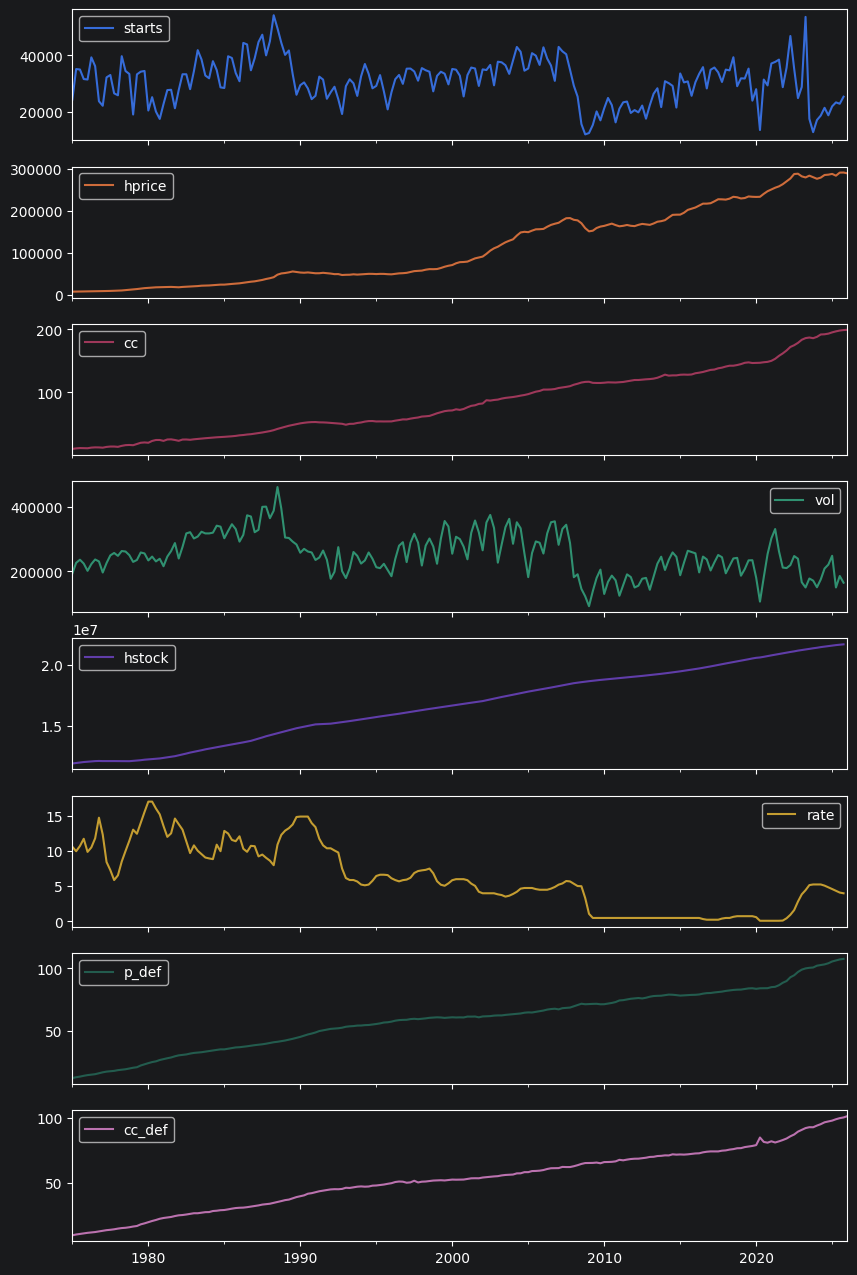

In [80]:
m.plot(subplots=True, figsize=(10, 2*len(m.columns)))